<a href="https://colab.research.google.com/github/StereoWings7/potential-octo-giggle/blob/main/load_module_save_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 別途test.ipynbでモジュール類をGoogle Driveにインストールした状態から始める
import os

In [2]:
# モジュール類を参照するディレクトリを指定する
package_path = '/content/drive/MyDrive/Colab\ Notebooks/my-site-packages/'
package_path_str = '/content/drive/MyDrive/Colab Notebooks/my-site-packages/'

In [3]:
# システムが上記ディレクトリを参照してくれるように、アペンドする
import sys
sys.path.append(package_path_str)

In [17]:
# あとは普通にロードするだけ
import d2l

In [5]:
# 必要なモジュールをロード
import torch
from torch import nn
from d2l import torch as d2l

In [15]:
# 目的のディレクトリに移動し、中身を確認
os.chdir('/content/drive/MyDrive/Colab Notebooks')
os.listdir()

['LPL_test.ipynb',
 'd2l_chap2.ipynb',
 '.ipynb_checkpoints',
 'load_module_save_model.ipynb',
 'my-site-packages',
 'test.ipynb']

In [6]:
def init_cnn(module):
    """Initialize weights for CNNs."""
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.xavier_uniform_(module.weight)

class LeNet(d2l.Classifier):
    """The LeNet-5 model."""
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.Sigmoid(),
            nn.LazyLinear(84), nn.Sigmoid(),
            nn.LazyLinear(num_classes))


In [7]:
def add_to_class(Class):
    """Register functions as methods in created class."""
    def wrapper(obj):
        setattr(Class, obj.__name__, obj)
    return wrapper

In [8]:
@d2l.add_to_class(d2l.Classifier)
def layer_summary(self, X_shape):
    X = torch.randn(*X_shape)
    for layer in self.net:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

model = LeNet()
model.layer_summary((1, 1, 28, 28))


Conv2d output shape:	 torch.Size([1, 6, 28, 28])
Sigmoid output shape:	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape:	 torch.Size([1, 6, 14, 14])
Conv2d output shape:	 torch.Size([1, 16, 10, 10])
Sigmoid output shape:	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape:	 torch.Size([1, 16, 5, 5])
Flatten output shape:	 torch.Size([1, 400])
Linear output shape:	 torch.Size([1, 120])
Sigmoid output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
Sigmoid output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


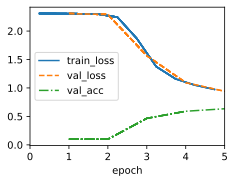

In [9]:
# わざと5エポックだけしか走らせない。残りの5エポックは再度読み込みして、そこからリスタートかけることで実行する。
trainer = d2l.Trainer(max_epochs=5, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model = LeNet(lr=0.1)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model, data)


In [11]:
# state_dictプロパティには重みづけ係数が辞書の形で含まれている
print(model.state_dict)

<bound method Module.state_dict of LeNet(
  (net): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Sigmoid()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Sigmoid()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=400, out_features=120, bias=True)
    (8): Sigmoid()
    (9): Linear(in_features=120, out_features=84, bias=True)
    (10): Sigmoid()
    (11): Linear(in_features=84, out_features=10, bias=True)
  )
)>


In [16]:
#PyTorchの機能で保存
torch.save(model.state_dict(), 'lenet.params')